In [1]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import openpyxl
import numpy as np

In [2]:
od_housing = pd.read_csv("/Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/informal_jobs/outputs/files/od_housing_amai_imputed.csv", low_memory=False)
# Data obtained from NSE broken down by AGEB 
nse_ageb = pd.read_excel("/Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/informal_jobs/data/NSE_por_AGEB_AMAI.xlsx")

In [3]:
# Final AMAI score
od_housing["puntos_amai_total"] = (
    od_housing["modelo_puntos_ultimo_estudio_jefe_hogar"]
    + od_housing["puntos_internet"]
    + od_housing["puntos_numero_autos_camionetas"]
    + od_housing["modelo_puntos_14_anos_trabajo_mes"]
    + od_housing["modelo_puntos_banos_completos"]
    + od_housing["modelo_puntos_cuartos_dormir"]
)

# AMAI socioeconomic level
amai_bins = [-np.inf, 48, 95, 116, 141, 168, 202, np.inf]
amai_labels = ["E", "D", "D+", "C-", "C", "C+", "A/B"]

od_housing["nivel_socioeconomico_amai"] = pd.cut(od_housing["puntos_amai_total"], bins=amai_bins, labels=amai_labels, right=False).astype("string")

In [4]:
od_housing

,folio_vivienda,fecha,municipio,ageb,centralidad,problema_movilidad_principal,problema_tp_principal,personas_en_vivienda,tenencia_vivienda,ingreso_mensual_hogar,...,prob_bathrooms_2_mas,prob_rooms_1,prob_rooms_2,prob_rooms_3,prob_rooms_4_mas,modelo_puntos_14_anos_trabajo_mes,modelo_puntos_banos_completos,modelo_puntos_cuartos_dormir,puntos_amai_total,nivel_socioeconomico_amai
0,1,2023-01-25 00:00:00+00:00,Tlajomulco,1409700251418,30F,Tiempos excesivos de traslado,La distancia a las paradas,5,Propia,"Más de $25,001",...,0.721995,0.010185,0.116451,0.470905,0.402459,38.910128,40.569402,26.125103,265.604632,A/B
1,2,2023-01-26 00:00:00+00:00,Guadalajara,1403900010859,09,Congestionamiento,El sobrecupo de personas en las unidades del t...,3,Rentada,"$3,001 y $7,000",...,0.065947,0.204763,0.620898,0.153914,0.020425,22.869987,19.997027,15.920013,101.787027,D+
2,3,2023-01-26 00:00:00+00:00,Guadalajara,1403900010539,09,Pavimento deteriorado,La distancia a las paradas,3,Prestada,No quiso responder,...,0.071462,0.593559,0.306492,0.083356,0.016593,21.838894,18.318272,12.183860,102.341027,D+
3,4,2023-01-26 00:00:00+00:00,Guadalajara,1403900010539,09,Falta de señalamientos,El tiempo de duración de viaje,3,Rentada,"Más de $25,001",...,0.327307,0.061466,0.505851,0.385099,0.047584,30.569045,31.187937,19.350402,153.107384,C
4,5,2023-01-26 00:00:00+00:00,Guadalajara,1403900010539,09,Congestionamiento,El sobrecupo de personas en las unidades del t...,6,Propia,"$7,001 y $10,000",...,0.098121,0.067207,0.428722,0.360466,0.143605,33.004357,18.579225,20.643750,144.227332,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17896,17963,2023-02-17 00:00:00+00:00,Tlaquepaque,1409800013322,18,Falta de estacionamiento,Trato del/de la chofer,4,Rentada,"$7,001 y $10,000",...,0.065089,0.157191,0.615691,0.200965,0.026154,27.562125,20.673759,16.768643,108.004527,D+
17897,17964,2023-02-17 00:00:00+00:00,Tlaquepaque,140980001110A,18,Falta de cruces peatonales,Trato del/de la chofer,6,Rentada,"$15,001 y $25,000",...,0.061404,0.179103,0.568744,0.200979,0.051174,29.464439,21.170237,16.993787,117.628464,C-
17898,17965,2023-02-17 00:00:00+00:00,Tlaquepaque,140980001110A,18,Insuficiente transporte público,El costo del viaje,2,Rentada,"$10,001 y $15,000",...,0.114960,0.403106,0.496601,0.085635,0.014658,16.672766,25.205581,13.694759,105.573106,D+
17899,17966,2023-04-15 00:00:00+00:00,Tonalá,1410100261709,45,Insuficiente transporte público,Falta de cubiertas para espera en las paradas,5,Rentada,No quiso responder,...,0.119961,0.103113,0.586649,0.271636,0.038602,32.528530,24.929520,17.965813,147.423863,C


In [5]:
# Data standarization
column_names = [
    "entidad",
    "nombre_entidad",
    "municipio",
    "nombre_municipio",
    "localidad",
    "nombre_localidad",
    "ageb",
    "ab_num_viviendas",
    "c_mas_num_viviendas",
    "c_num_viviendas",
    "c_menos_num_viviendas",
    "d_mas_num_viviendas",
    "d_num_viviendas",
    "e_num_viviendas",
    "nivel_predominante",
    "num_viviendas",
    "tamano_localidad"
]

nse_ageb.columns = column_names
nse_ageb = nse_ageb.iloc[1:].reset_index(drop=True)
nse_ageb = nse_ageb.replace("N/D", pd.NA)

In [6]:
# We keep only the data from Jalisco state
nse_ageb_jalisco = nse_ageb.loc[nse_ageb["nombre_entidad"].eq("Jalisco")]

In [7]:
# We keep only the data from the municipalities of interest from Jalisco
municipalities_of_interest = {
    "Guadalajara",
    "Ixtlahuacán de los Membrillos",
    "Juanacatlán",
    "El Salto",
    "Tlajomulco de Zúñiga",
    "San Pedro Tlaquepaque",
    "Tonalá",
    "Zapopan",
    "Zapotlanejo"
}

nse_ageb_jalisco = nse_ageb_jalisco[nse_ageb_jalisco["nombre_municipio"].isin(municipalities_of_interest)].copy()
nse_ageb_jalisco.reset_index(drop=True, inplace=True)

nse_ageb_jalisco.drop(columns=["entidad", "nombre_entidad"], inplace=True) # Drop unnecesary (repetitive) columns

In [8]:
nse_ageb_jalisco["municipio"] = nse_ageb_jalisco["municipio"].astype("Int64")
nse_ageb_jalisco["nombre_municipio"] = nse_ageb_jalisco["nombre_municipio"].astype("string")
nse_ageb_jalisco["localidad"] = nse_ageb_jalisco["localidad"].astype("Int64")
nse_ageb_jalisco["nombre_localidad"] = nse_ageb_jalisco["nombre_localidad"].astype("string")
nse_ageb_jalisco["ageb"] = nse_ageb_jalisco["ageb"].astype("string")
nse_ageb_jalisco["ab_num_viviendas"] = nse_ageb_jalisco["ab_num_viviendas"].astype("Int64")
nse_ageb_jalisco["c_mas_num_viviendas"] = nse_ageb_jalisco["c_mas_num_viviendas"].astype("Int64")
nse_ageb_jalisco["c_num_viviendas"] = nse_ageb_jalisco["c_num_viviendas"].astype("Int64")
nse_ageb_jalisco["c_menos_num_viviendas"] = nse_ageb_jalisco["c_menos_num_viviendas"].astype("Int64")
nse_ageb_jalisco["d_mas_num_viviendas"] = nse_ageb_jalisco["d_mas_num_viviendas"].astype("Int64")
nse_ageb_jalisco["d_num_viviendas"] = nse_ageb_jalisco["d_num_viviendas"].astype("Int64")
nse_ageb_jalisco["e_num_viviendas"] = nse_ageb_jalisco["e_num_viviendas"].astype("Int64")
nse_ageb_jalisco["nivel_predominante"] = nse_ageb_jalisco["nivel_predominante"].astype("string")
nse_ageb_jalisco["num_viviendas"] = nse_ageb_jalisco["num_viviendas"].astype("Int64")
nse_ageb_jalisco["tamano_localidad"] = nse_ageb_jalisco["tamano_localidad"].astype("string")

We compute the AMAI distribution of housing units across socioeconomic levels within each AGEB as

$$P(NSE = k \mid AGEB = g) = \frac{N_{g,k}}{N_g},$$

where $N_{g,k}$ are the number of housing units classified under socioeconomic level $k$ within AGEB $g$ , and $N_g$ are the total number of housing in that AGEB $g$.

In [9]:
nse_mapping = {
    "ab_num_viviendas": "ab_probability",
    "c_mas_num_viviendas": "c_mas_probability",
    "c_num_viviendas": "c_probability",
    "c_menos_num_viviendas": "c_menos_probability",
    "d_mas_num_viviendas": "d_mas_probability",
    "d_num_viviendas": "d_probability",
    "e_num_viviendas": "e_probability"
}

for count_column, probability_column in nse_mapping.items():
    nse_ageb_jalisco[probability_column] = nse_ageb_jalisco[count_column] / nse_ageb_jalisco["num_viviendas"]

base_columns = [
    "municipio", 
    "nombre_municipio",
    "localidad",
    "nombre_localidad",
    "ageb"
]

nse_columns = [
    "ab_num_viviendas", "ab_probability",
    "c_mas_num_viviendas", "c_mas_probability",
    "c_num_viviendas", "c_probability",
    "c_menos_num_viviendas", "c_menos_probability",
    "d_mas_num_viviendas", "d_mas_probability",
    "d_num_viviendas", "d_probability",
    "e_num_viviendas", "e_probability"
]

final_columns = base_columns + nse_columns + [
    "nivel_predominante",
    "num_viviendas",
    "tamano_localidad"
]

nse_ageb_jalisco = nse_ageb_jalisco[final_columns]

## Spatial calibration

We have two sources of information: the household-level socioeconomic classification obtained from the machine learning models, and the observed distribution of socioeconomic levels within each AGEB.

First, for each household $i$, the expected AMAI score is calculated as


$$\hat S_i^{\mathrm{AMAI}} = \sum_{j\in\mathcal M} \sum_{k\in\mathcal K_j} P(Y_{ij}=k\mid X_i)s_{jk} + \sum_{j\in\mathcal O}s_j(z_{ij}),$$


where $\mathcal M$ are the attributes estimated from the machine learning models, $\mathcal O$ the observed attributes, and $s_{jk}$ the AMAI score from category $k$ of attribute $j$.

The initial household socioeconomic level is then obtained from the AMAI classification rule,

$$\text{NSE}_i = C\left(\hat S_i^{\mathrm{AMAI}}\right),$$

where $C(\cdot)$ maps the total AMAI score into one of the seven socioeconomic levels: $\{E,D,D+,C-,C,C+,A/B\}$.


Then, for each AGEB $g$, we have the observed distribution of housing units across socioeconomic levels. For $N_{gk}$ number of housing units classified under socioeconomic level $k$ within AGEB $g$ and $N_g$ total housing units in that ageb; the distribution is calculated as

$$p_{gk} = P(NSE=k\mid AGEB=g) = \frac{N_{gk}}{N_g}.$$

To consider this spatial information, households within each AGEB are ordered according to their estimated AMAI score $\hat S_i^{\mathrm{AMAI}}$. After ordering households within each AGEB according to their estimated AMAI score, their relative socioeconomic position is represented by the weighted mid-rank

$$ r_{ig} = \frac{ \sum_{j=1}^{i}w_{jg}-w_{ig}/2 }{ \sum_{j=1}^{n_g}w_{jg} },$$

in which we acount for the fact that OD observations may represent different numbers of households in the population through their expansion factors $w_j$. Subtracting half of the household's weight places the observation at the midpoint of the population mass it represents rather than at its upper cumulative boundary.

The AGEB socioeconomic probabilities are then converted into cumulative probabilities,


$$F_{gk} = \sum_{\ell\leq k}p_{g\ell}.$$

Finally, the spatially calibrated socioeconomic level is assigned according to the interval of the cumulative AGEB distribution in which the household's weighted rank falls,

$$NSE_{ig}^{\mathrm{cal}} = k \quad\text{if}\quad F_{g,k-1}\leq r_{ig}<F_{gk}.$$

Thus, the household-level model determines the relative socioeconomic position of each household within its AGEB, while the external AMAI distribution determines the proportion of households assigned to each socioeconomic level.

In [10]:
# OD AGEB IDENTIFIERS
od_housing["ageb"] = od_housing["ageb"].astype("string")
urban_ageb_mask = od_housing["ageb"].str.len() == 13
od_housing["municipio_clave"] = pd.to_numeric(od_housing["ageb"].where(urban_ageb_mask).str[2:5], errors="coerce").astype("Int64")
od_housing["localidad_clave"] = pd.to_numeric(od_housing["ageb"].where(urban_ageb_mask).str[5:9], errors="coerce").astype("Int64")
od_housing["ageb_clave"] = od_housing["ageb"].where(urban_ageb_mask).str[9:13]

In [11]:
ageb_probability_columns = [
    "e_probability",
    "d_probability",
    "d_mas_probability",
    "c_menos_probability",
    "c_probability",
    "c_mas_probability",
    "ab_probability"
]

ageb_calibration_data = nse_ageb_jalisco[["municipio", "localidad", "ageb"] + ageb_probability_columns].copy()
ageb_calibration_data["ageb"] = ageb_calibration_data["ageb"].astype("string").str.zfill(4)
od_housing = od_housing.merge(ageb_calibration_data, left_on=["municipio_clave", "localidad_clave", "ageb_clave"], right_on=["municipio", "localidad", "ageb"], how="left", validate="many_to_one", suffixes=("", "_nse_ageb"))

In [12]:
nse_levels = [
    "E",
    "D",
    "D+",
    "C-",
    "C",
    "C+",
    "A/B"
]

nse_probability_columns = [
    "e_probability",
    "d_probability",
    "d_mas_probability",
    "c_menos_probability",
    "c_probability",
    "c_mas_probability",
    "ab_probability"
]

def calibrate_ageb_nse(group):
    probability_values = group[nse_probability_columns].iloc[0].to_numpy(dtype=float)

    # If spatial probabilities are incomplete, keep the original micro-level NSE
    if np.isnan(probability_values).any():
        group["nivel_socioeconomico_amai_calibrado"] = group["nivel_socioeconomico_amai"]
        return group

    # Normalize AGEB probabilities
    probability_sum = probability_values.sum()

    if probability_sum <= 0:
        group["nivel_socioeconomico_amai_calibrado"] = group["nivel_socioeconomico_amai"]
        return group

    probability_values = probability_values / probability_sum
    cumulative_probabilities = np.cumsum(probability_values)
    cumulative_probabilities[-1] = 1.0

    # Sort households from lowest to highest micro-level AMAI score
    group = group.sort_values("puntos_amai_total").copy()

    # Compute weighted percentile within the AGEB
    weights = group["ponderador"].astype(float)
    cumulative_rank = ((weights.cumsum() - weights / 2) / weights.sum()).to_numpy()

    # Assign each household according to the cumulative AGEB NSE distribution
    category_index = np.searchsorted(cumulative_probabilities, cumulative_rank, side="right")
    category_index = np.clip(category_index, 0, len(nse_levels) - 1)

    group["nivel_socioeconomico_amai_calibrado"] = np.array(nse_levels)[category_index]

    return group

calibration_columns = ["municipio_clave", "localidad_clave", "ageb_clave"]
od_housing = od_housing.groupby(calibration_columns, dropna=False, group_keys=False).apply(calibrate_ageb_nse).reset_index(drop=True)

In [13]:
od_housing

,folio_vivienda,fecha,municipio,ageb,centralidad,problema_movilidad_principal,problema_tp_principal,personas_en_vivienda,tenencia_vivienda,ingreso_mensual_hogar,...,localidad,ageb_nse_ageb,e_probability,d_probability,d_mas_probability,c_menos_probability,c_probability,c_mas_probability,ab_probability,nivel_socioeconomico_amai_calibrado
0,11918,2023-03-27 00:00:00+00:00,Guadalajara,1403900010026,69A,NaN,NaN,3,Propia,No quiso responder,...,1,0026,0.0,0.016097,0.026157,0.070423,0.177062,0.311871,0.39839,C-
1,11883,2023-03-27 00:00:00+00:00,Guadalajara,1403900010026,69A,NaN,NaN,2,Propia,No quiso responder,...,1,0026,0.0,0.016097,0.026157,0.070423,0.177062,0.311871,0.39839,C
2,11873,2023-03-27 00:00:00+00:00,Guadalajara,1403900010026,69A,Falta de señalamientos,Poca frecuencia de paso en la noche,2,Propia,No quiso responder,...,1,0026,0.0,0.016097,0.026157,0.070423,0.177062,0.311871,0.39839,C
3,11898,2023-03-27 00:00:00+00:00,Guadalajara,1403900010026,69A,NaN,NaN,3,Propia,No sabe,...,1,0026,0.0,0.016097,0.026157,0.070423,0.177062,0.311871,0.39839,C+
4,11887,2023-03-27 00:00:00+00:00,Guadalajara,1403900010026,69A,NaN,NaN,4,Propia,No quiso responder,...,1,0026,0.0,0.016097,0.026157,0.070423,0.177062,0.311871,0.39839,C+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17896,17953,2023-04-11 00:00:00+00:00,Zapotlanejo,141240029,48F,Insuficiente transporte público,La falta de comodidad de las unidades del tran...,2,Rentada,"$7,001 y $10,000",...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,C-
17897,17954,2023-04-11 00:00:00+00:00,Zapotlanejo,141240029,48F,Calles inundadas,Poca frecuencia de paso en el día,5,Rentada,"$3,001 y $7,000",...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,D+
17898,17958,2023-04-21 00:00:00+00:00,Tlajomulco,14097059A,02F,Congestionamiento,El tiempo de duración de viaje,3,Rentada,No quiso responder,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,C+
17899,17959,2023-03-13 00:00:00+00:00,Tlaquepaque,140980012,57,Falta de cruces peatonales,La falta de comodidad de las unidades del tran...,3,Rentada,No quiso responder,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,C+


## Plot

In [14]:
agebs = gpd.read_file("/Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/asignacion_atributos/resultados_asignacion_atributos/zonas_agebs.gpkg", layer="zonas_agebs")

In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib import font_manager
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
output_directory = ROOT / "outputs" / "figures"
output_directory.mkdir(parents=True, exist_ok=True)

In [16]:
nse_order = ["E", "D", "D+", "C-", "C", "C+", "A/B"]

nse_color_mapping = {
    "E": "#b2182b",
    "D": "#d6604d",
    "D+": "#f4a582",
    "C-": "#fddbc7",
    "C": "#d1e5f0",
    "C+": "#67a9cf",
    "A/B": "#2166ac"
}

no_data_color = "#d9d9d9"

In [17]:
od_housing["clave_ageb"] = od_housing["ageb"].astype("string").str.strip()
od_housing_urban = od_housing.loc[od_housing["clave_ageb"].str.len() == 13].copy()

nse_ageb_jalisco["clave_ageb"] = "14" + nse_ageb_jalisco["municipio"].astype("string").str.zfill(3) + nse_ageb_jalisco["localidad"].astype("string").str.zfill(4) + nse_ageb_jalisco["ageb"].astype("string").str.zfill(4)
agebs["clave_ageb"] = agebs["clave_ageb"].astype("string").str.strip()

def get_predominant_nse_by_ageb(data, nse_column, output_column):
    distribution = data.groupby(["clave_ageb", nse_column], as_index=False)["ponderador"].sum().rename(columns={"ponderador": "weighted_housing"})
    distribution["weighted_share"] = distribution["weighted_housing"] / distribution.groupby("clave_ageb")["weighted_housing"].transform("sum")
    predominant = distribution.loc[distribution.groupby("clave_ageb")["weighted_share"].idxmax(), ["clave_ageb", nse_column, "weighted_share"]].rename(columns={nse_column: output_column, "weighted_share": f"{output_column}_share"}).reset_index(drop=True)
    return predominant

od_ageb_original = get_predominant_nse_by_ageb(od_housing_urban, "nivel_socioeconomico_amai", "nivel_predominante_od")
od_ageb_calibrated = get_predominant_nse_by_ageb(od_housing_urban, "nivel_socioeconomico_amai_calibrado", "nivel_predominante_od_calibrado")


# Merge map data
agebs_comparison = agebs.merge(nse_ageb_jalisco[["clave_ageb", "nivel_predominante"]], on="clave_ageb", how="left", validate="one_to_one")
agebs_comparison = agebs_comparison.merge(od_ageb_original, on="clave_ageb", how="left", validate="one_to_one")
agebs_comparison = agebs_comparison.merge(od_ageb_calibrated, on="clave_ageb", how="left", validate="one_to_one")

agebs_comparison["color_amai"] = agebs_comparison["nivel_predominante"].map(nse_color_mapping).fillna(no_data_color)
agebs_comparison["color_od"] = agebs_comparison["nivel_predominante_od"].map(nse_color_mapping).fillna(no_data_color)
agebs_comparison["color_od_calibrated"] = agebs_comparison["nivel_predominante_od_calibrado"].map(nse_color_mapping).fillna(no_data_color)

In [18]:
# Common agebs for distribution analysis
nse_probability_columns = [
    "e_probability",
    "d_probability",
    "d_mas_probability",
    "c_menos_probability",
    "c_probability",
    "c_mas_probability",
    "ab_probability"
]

complete_amai_agebs = nse_ageb_jalisco.loc[nse_ageb_jalisco[nse_probability_columns].notna().all(axis=1), "clave_ageb"].unique()
od_agebs = od_housing_urban["clave_ageb"].dropna().unique()
common_agebs = np.intersect1d(complete_amai_agebs, od_agebs)
print(f"AGEBs with complete AMAI data and OD observations: {len(common_agebs):,}")

AGEBs with complete AMAI data and OD observations: 902


In [19]:
# AMAI distribution
amai_probability_mapping = {
    "E": "e_probability",
    "D": "d_probability",
    "D+": "d_mas_probability",
    "C-": "c_menos_probability",
    "C": "c_probability",
    "C+": "c_mas_probability",
    "A/B": "ab_probability"
}

amai_comparison = nse_ageb_jalisco.loc[nse_ageb_jalisco["clave_ageb"].isin(common_agebs)].copy()
amai_distribution = pd.Series({level: np.average(amai_comparison[probability_column].astype(float), weights=amai_comparison["num_viviendas"].astype(float))
    for level, probability_column in amai_probability_mapping.items()})
amai_distribution = amai_distribution / amai_distribution.sum()

# OD distributions
od_comparison = od_housing_urban.loc[od_housing_urban["clave_ageb"].isin(common_agebs)].copy()

def get_weighted_nse_distribution(data, nse_column):
    distribution = data.groupby(nse_column)["ponderador"].sum().reindex(nse_order, fill_value=0)
    return distribution / distribution.sum()

od_original_distribution = get_weighted_nse_distribution(od_comparison, "nivel_socioeconomico_amai")
od_calibrated_distribution = get_weighted_nse_distribution(od_comparison, "nivel_socioeconomico_amai_calibrado")

# Distribution comparison
distribution_comparison = pd.DataFrame({
    "AMAI por AGEB": amai_distribution,
    "OD antes de calibración": od_original_distribution,
    "OD después de calibración": od_calibrated_distribution
}).T * 100
distribution_comparison = distribution_comparison[nse_order]


# Difference from AMAI
difference_from_amai = pd.DataFrame({
    "Antes de calibración": (od_original_distribution - amai_distribution) * 100,
    "Después de calibración": (od_calibrated_distribution - amai_distribution) * 100
}).T

difference_from_amai = difference_from_amai[nse_order]

print("\nNSE distribution [%]")
display(distribution_comparison.round(2))

print("\nDifference from AMAI [percentage points]")
display(difference_from_amai.round(2))



NSE distribution [%]


,E,D,D+,C-,C,C+,A/B
AMAI por AGEB,3.07,19.66,15.11,17.38,18.27,16.67,9.85
OD antes de calibración,0.97,13.81,15.14,23.11,19.50,18.58,8.88
OD después de calibración,2.15,19.89,15.20,17.45,18.58,16.87,9.87



Difference from AMAI [percentage points]


,E,D,D+,C-,C,C+,A/B
Antes de calibración,-2.11,-5.84,0.03,5.74,1.24,1.92,-0.97
Después de calibración,-0.92,0.23,0.09,0.07,0.31,0.21,0.01


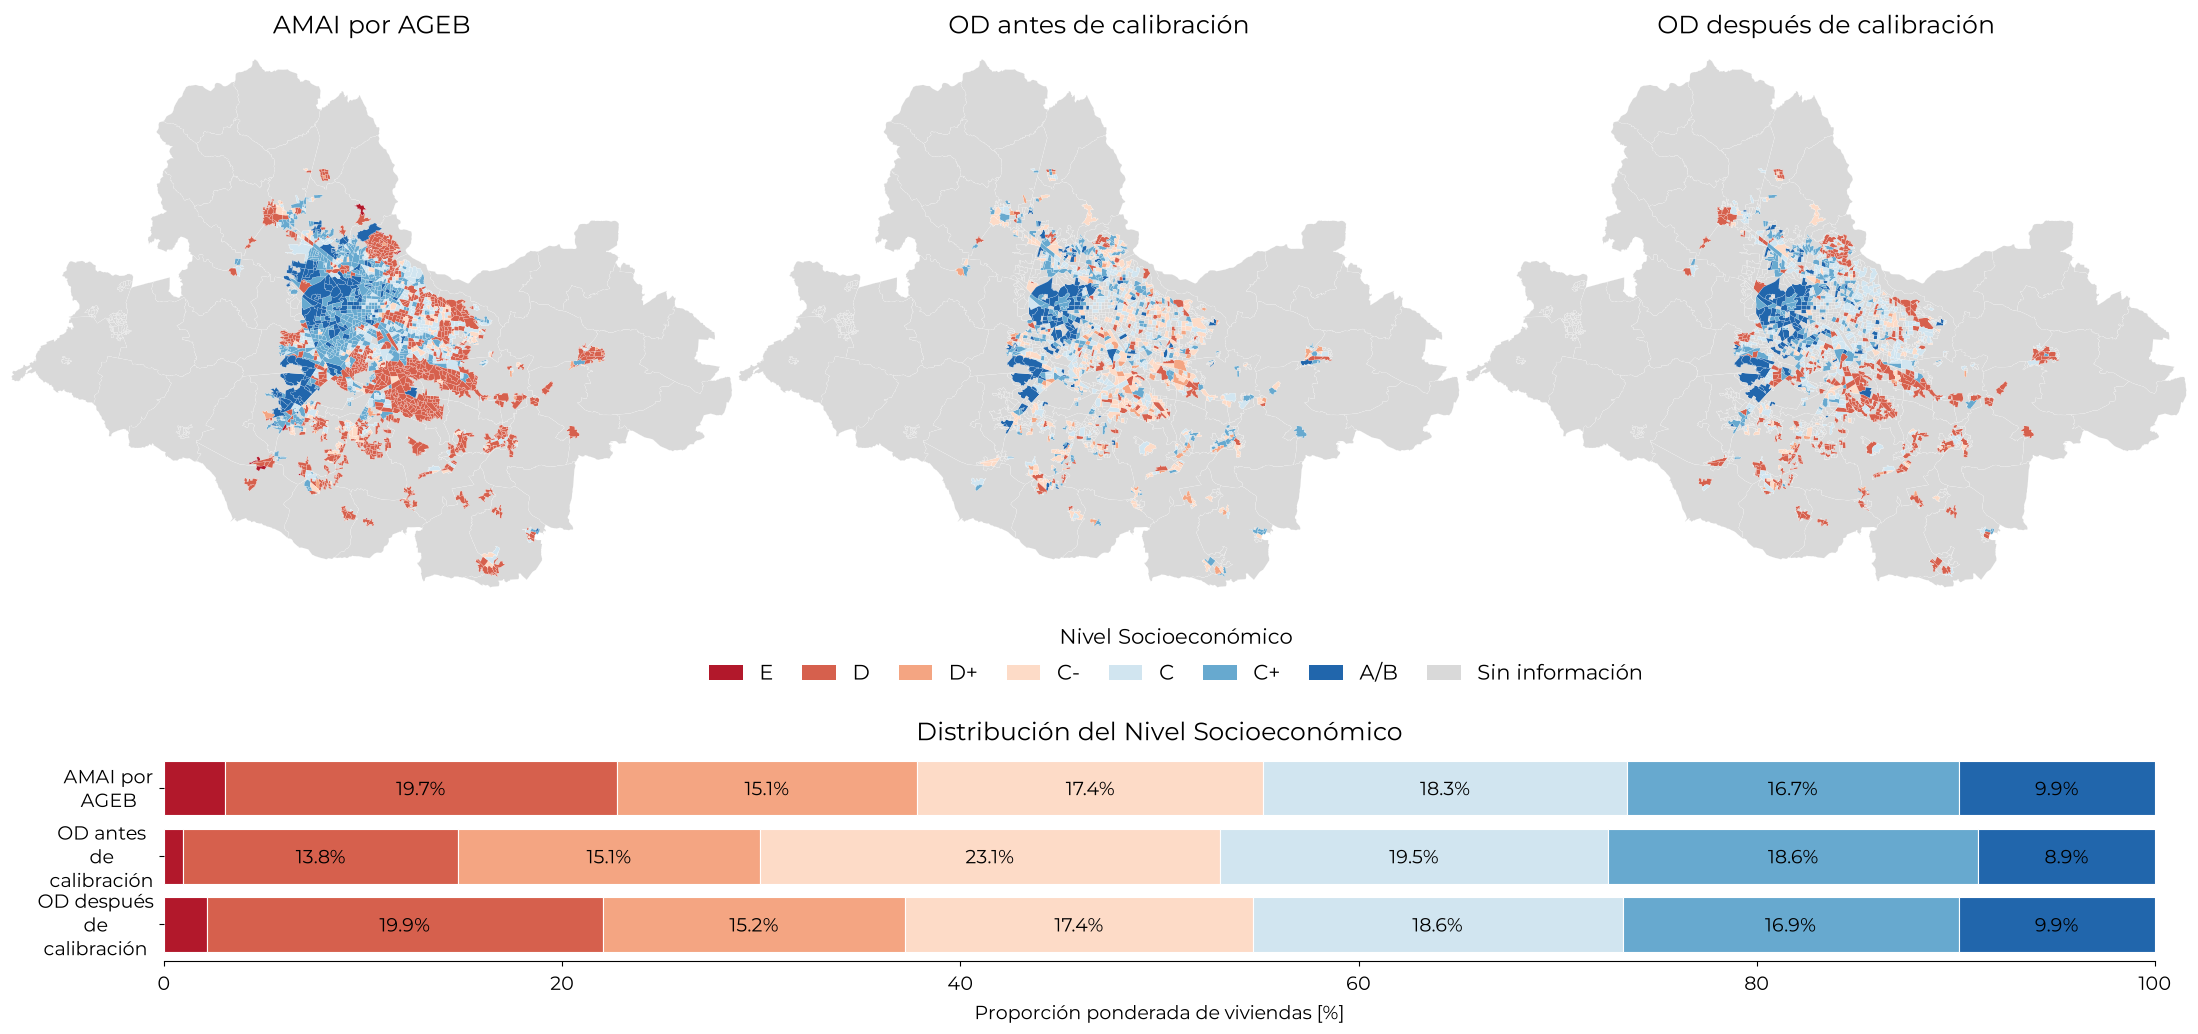

In [20]:
# Buscar e incorporar fuentes Montserrat instaladas en el sistema
montserrat_fonts = [font for font in font_manager.findSystemFonts() if "Montserrat" in Path(font).stem]
for font in montserrat_fonts:
    font_manager.fontManager.addfont(font)

plt.rcParams["font.family"] = "Montserrat"
plt.rcParams["axes.unicode_minus"] = False

fig = plt.figure(figsize=(22, 10.5))
fig.patch.set_alpha(0)

###############
# CONFIGURATION
 ###############

# Map grid
gs_maps = fig.add_gridspec(nrows=1, ncols=3, left=0.005, right=0.995, top=0.925, bottom=0.30, wspace=0.005)
ax_amai = fig.add_subplot(gs_maps[0, 0])
ax_od = fig.add_subplot(gs_maps[0, 1])
ax_od_calibrated = fig.add_subplot(gs_maps[0, 2])

# Legend axis: left, bottom, width, height
ax_legend = fig.add_axes([0.08, 0.335, 0.91, 0.045])

# Distribution axis: left, bottom, width, height
ax_distribution = fig.add_axes([0.075, 0.065, 0.905, 0.20])

# Map bounds
minx, miny, maxx, maxy = agebs_comparison.total_bounds
x_range = maxx - minx
y_range = maxy - miny

# Small padding
x_padding = x_range * 0.002
y_padding = y_range * 0.002

###############################
# AMAI PREDOMINANT NSE BY AGEB
###############################

agebs_comparison.plot(ax=ax_amai, color=agebs_comparison["color_amai"], edgecolor="white", linewidth=0.10)
ax_amai.set_title("AMAI por AGEB", fontsize=18, pad=18)

################################
# OD BEFORE SPATIAL CALIBRATION
################################

agebs_comparison.plot(ax=ax_od, color=agebs_comparison["color_od"], edgecolor="white", linewidth=0.10)
ax_od.set_title("OD antes de calibración", fontsize=18, pad=18)

##############################
# OD AFTER SPATIAL CALIBRATION
##############################

agebs_comparison.plot(ax=ax_od_calibrated, color=agebs_comparison["color_od_calibrated"], edgecolor="white", linewidth=0.10)
ax_od_calibrated.set_title("OD después de calibración", fontsize=18, pad=18)

################
# MAP FORMATTING
################

map_axes = [ax_amai, ax_od, ax_od_calibrated]
for ax in map_axes:
    ax.set_xlim(minx - x_padding, maxx + x_padding)
    ax.set_ylim(miny - y_padding, maxy + y_padding)

    # Preserve geographic proportions
    ax.set_aspect("equal", adjustable="box")
    ax.set_axis_off()
    ax.set_facecolor("none")

# Align maps toward the outside
ax_amai.set_anchor("NW") # First map uses all available space toward the LEFT
ax_od.set_anchor("N") # Middle map stays centered
ax_od_calibrated.set_anchor("NE") # Last map uses all available space toward the RIGHT

# Common legend
legend_elements = [Patch(facecolor=nse_color_mapping[level], edgecolor="none", label=level) for level in nse_order]
legend_elements.append(Patch(facecolor=no_data_color, edgecolor="none", label="Sin información"))
ax_legend.axis("off")
ax_legend.legend(handles=legend_elements, title="Nivel Socioeconómico", loc="center", ncol=8, frameon=False, fontsize=15, title_fontsize=15, handlelength=1.6, columnspacing=1.4)

#############################
# NSE DISTRIBUTION COMPARISON
#############################

left = np.zeros(len(distribution_comparison))
for level in nse_order:
    values = distribution_comparison[level].to_numpy()
    ax_distribution.barh(distribution_comparison.index, values, left=left, color=nse_color_mapping[level], edgecolor="white", linewidth=0.8)

    for row_index, value in enumerate(values): # Percentage labels
        if value >= 4:
            ax_distribution.text(left[row_index] + value / 2, row_index, f"{value:.1f}%", ha="center", va="center", fontsize=14)
    left += values

# Distribution formatting
ax_distribution.set_title("Distribución del Nivel Socioeconómico", fontsize=18, pad=8)
ax_distribution.set_xlabel("Proporción ponderada de viviendas [%]", fontsize=14)
ax_distribution.set_xlim(0, 100)
ax_distribution.invert_yaxis()
ax_distribution.tick_params(axis="x", labelsize=14)
ax_distribution.tick_params(axis="y", labelsize=14, pad=4)
ax_distribution.set_yticks(
    np.arange(len(distribution_comparison))
)

ax_distribution.set_yticklabels([
    "AMAI por\nAGEB",
    "OD antes\nde\ncalibración",
    "OD después\nde\ncalibración"
])

for label in ax_distribution.get_yticklabels():
    label.set_horizontalalignment("right")
    label.set_verticalalignment("center")
    label.set_multialignment("center")

ax_distribution.grid(False)
ax_distribution.set_facecolor("none")

ax_distribution.spines["top"].set_visible(False)
ax_distribution.spines["right"].set_visible(False)
ax_distribution.spines["left"].set_visible(False)
ax_distribution.grid(False)
ax_distribution.set_facecolor("none")

# Remove unnecessary borders
ax_distribution.spines["top"].set_visible(False)
ax_distribution.spines["right"].set_visible(False)
ax_distribution.spines["left"].set_visible(False)

# Save figure
png_path = output_directory / "nse_spatial_calibration_results.png"
pdf_path = output_directory / "nse_spatial_calibration_results.pdf"
plt.savefig(png_path, dpi=600, transparent=True)
plt.savefig(pdf_path, transparent=True)

plt.show()

In [21]:
od_housing.drop(columns=["clave_ageb"], inplace=True)
files_output_directory = ROOT / "outputs" / "files"
files_output_directory.mkdir(parents=True, exist_ok=True)

od_housing.to_csv(files_output_directory / "od_housing_with_economic_level.csv", index=False, encoding="utf-8-sig")
nse_ageb_jalisco.to_csv(files_output_directory / "nse_ageb_jalisco.csv", index=False, encoding="utf-8-sig")